# 11. Extract user comments from a web forum or blog post using web scraping. Perform sentiment analysis on the extracted data and identify the overall tone of the discussion. Visualize the sentiment distribution using a pie chart or bar graph..

use `SentimentIntensityAnalyzer` from `nltk.sentiment`


Extracted Comments:

                                             Comment
0       I absolutely love this post! Great insights.
1    This article is okay, but it could be improved.
2  I didn't find this useful at all. Very disappo...
3                        Fantastic work! Keep it up.
4               Not sure if I agree with this point.
5  The author did an amazing job explaining the t...
6        Too long and boring. Lost interest halfway.
7         Pretty informative and easy to understand.
8  Terrible explanation, it was confusing and vague.
9      Excellent! This was really helpful and clear.

Sentiment Analysis Results:

                                             Comment  Sentiment_Score  \
0       I absolutely love this post! Great insights.           0.8716   
1    This article is okay, but it could be improved.           0.6808   
2  I didn't find this useful at all. Very disappo...          -0.0305   
3                        Fantastic work! Keep it up.           0.5983   


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Levono\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


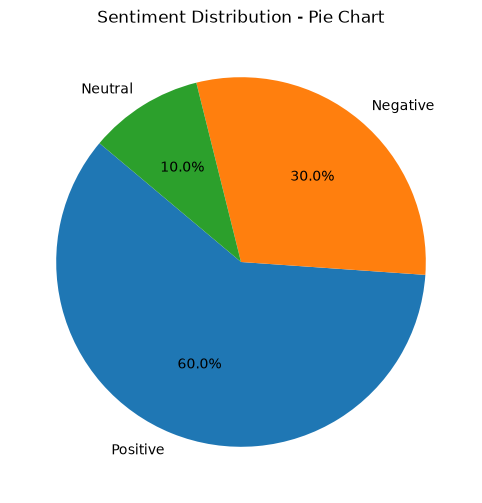

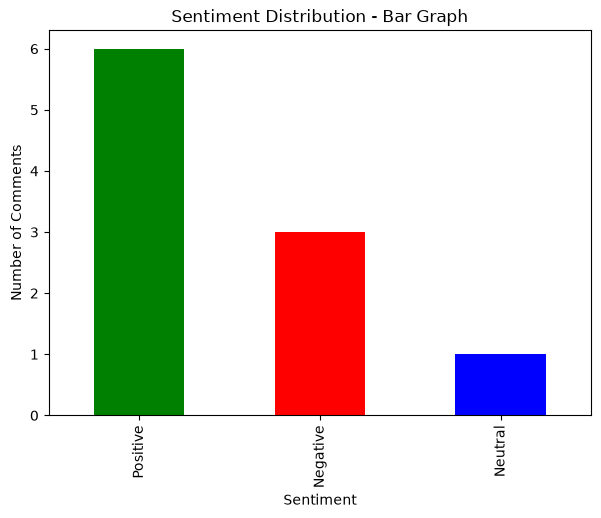

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
comments = [
"I absolutely love this post! Great insights.",
"This article is okay, but it could be improved.",
"I didn't find this useful at all. Very disappointing.",
"Fantastic work! Keep it up.",
"Not sure if I agree with this point.",
"The author did an amazing job explaining the topic.",
"Too long and boring. Lost interest halfway.",
"Pretty informative and easy to understand.",
"Terrible explanation, it was confusing and vague.",
"Excellent! This was really helpful and clear."
]

df = pd.DataFrame(comments, columns=['Comment'])
print("\nExtracted Comments:\n")
print(df)

sia = SentimentIntensityAnalyzer()

df['Sentiment_Score'] = df['Comment'].apply(lambda x: sia.polarity_scores(x)['compound'])

def categorize_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment_Score'].apply(categorize_sentiment)

print("\nSentiment Analysis Results:\n")
print(df)

sentiment_counts = df['Sentiment'].value_counts()
overall_tone = sentiment_counts.idxmax()

print(f"\nOverall Tone of Discussion: {overall_tone}")

plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution - Pie Chart')
plt.show()

plt.figure(figsize=(7,5))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution - Bar Graph')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()